In [1]:
import h5py
import numpy as np
import glob
from torch.utils.data import Dataset, DataLoader
import torchcvnn.nn as c_nn
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

### Test loading

In [2]:
path = "/mnt/i/mridata/brain_multicoil_train_batch_0/multicoil_train/file_brain_AXT2_200_2000057.h5"

In [3]:
activations_to_test = ["modrelu", "zrelu", "cardioid", "c_relu", "c_sigmoid", "c_tanh", "c_elu", "c_gelu"]

In [4]:
with h5py.File(path, "r") as f:
    print("Keys:", list(f.keys()))
    kspace = f["kspace"][:]      # raw k-space
    print("kspace shape:", kspace.shape, "dtype:", kspace.dtype)

    if "reconstruction_rss" in f:
        rss = f["reconstruction_rss"][:]
        print("reconstruction_rss shape:", rss.shape, "dtype:", rss.dtype)

    # look at attributes (metadata)
    attrs = dict(f.attrs)
    print("Attributes:", attrs.keys())

Keys: ['ismrmrd_header', 'kspace', 'reconstruction_rss']
kspace shape: (16, 20, 768, 396) dtype: complex64
reconstruction_rss shape: (16, 384, 384) dtype: float32
Attributes: dict_keys(['acquisition', 'max', 'norm', 'patient_id'])


In [5]:
s = kspace.shape[0] // 2
k_slice = kspace[s]  # [coils, Ny, Nx]
rss_slice = rss[s]   # [Ny, Nx] (if available)

(np.float64(-0.5), np.float64(395.5), np.float64(767.5), np.float64(-0.5))

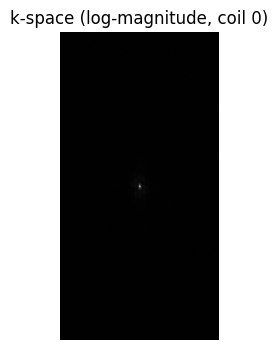

In [6]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("k-space (log-magnitude, coil 0)")
plt.imshow(np.log1p(np.abs(k_slice[0])), cmap='gray')
plt.axis('off')

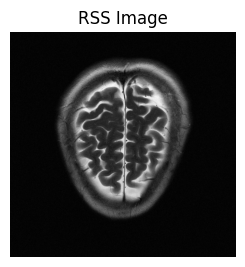

In [7]:
if rss is not None:
    plt.subplot(1,2,2)
    plt.title("RSS Image")
    plt.imshow(rss_slice, cmap='gray')
    plt.axis('off')
else:
    img = np.fft.ifft2(k_slice, norm='ortho')
    img_rss = np.sqrt(np.sum(np.abs(img)**2, axis=0))
    plt.subplot(1,2,2)
    plt.title("RSS Image (computed)")
    plt.imshow(img_rss, cmap='gray')
    plt.axis('off')

plt.show()

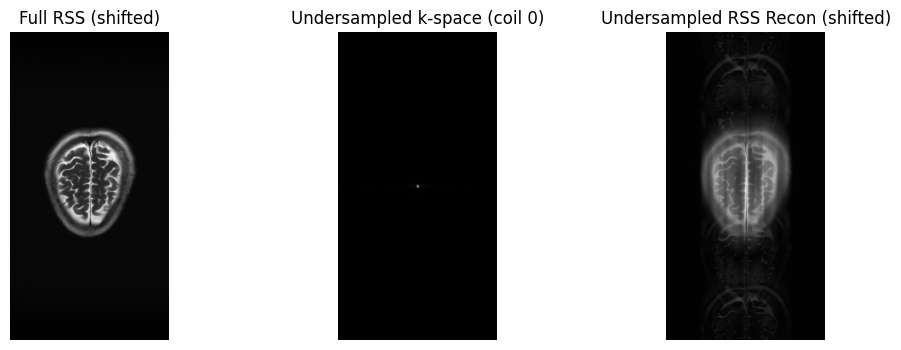

In [8]:
def simple_mask(Ny, accel=4):
    mask = np.zeros(Ny, dtype=np.float32)
    mask[::accel] = 1.0
    # keep some low-frequency center lines
    center = Ny // 2
    mask[center-4:center+4] = 1.0
    return mask

Ny, Nx = k_slice.shape[1], k_slice.shape[2]
mask = simple_mask(Ny, accel=4)[:, None]   # [Ny,1]
k_und = k_slice * mask                     # [coils,Ny,Nx]


# Full recon in image space
img_full = np.fft.ifft2(k_slice, norm="ortho")        # [coils,Ny,Nx]
img_full_rss = np.sqrt(np.sum(np.abs(img_full)**2, axis=0))  # [Ny,Nx]

# SHIFT for visualization
img_full_rss_disp = np.fft.fftshift(img_full_rss)  


# IFFT in image space
img_und = np.fft.ifft2(k_und, norm="ortho")          # [coils,Ny,Nx]
img_und_rss = np.sqrt(np.sum(np.abs(img_und)**2, axis=0))   # [Ny,Nx]

# fftshift only for display
img_und_rss_disp  = np.fft.fftshift(img_und_rss)
img_full_rss_disp = np.fft.fftshift(img_full_rss)   # from before

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Full RSS (shifted)")
plt.imshow(img_full_rss_disp, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Undersampled k-space (coil 0)")
plt.imshow(np.log1p(np.abs(k_und[0])), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Undersampled RSS Recon (shifted)")
plt.imshow(img_und_rss_disp, cmap="gray")
plt.axis("off")
plt.show()


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
def rss_combine(img_mc):
    """
    Root-sum-of-squares coil combination.
    img_mc: [num_coils, Ny, Nx], complex
    returns: [Ny, Nx], real
    """
    return torch.sqrt((img_mc.abs() ** 2).sum(dim=0) + 1e-8)

In [11]:
def simple_mask(Ny, accel=4, device="cpu"):
    mask = torch.zeros(Ny, dtype=torch.float32, device=device)
    mask[::accel] = 1.0
    center = Ny // 2
    mask[center-4:center+4] = 1.0
    return mask


### For bulk dataset in the folder

In [44]:
class FastMRIDataset(Dataset):
    def __init__(self, h5_paths, accel=4, max_slices=None):
        self.paths = h5_paths
        self.accel = accel

        self.samples = []  # list of (path, slice_idx)
        for p in self.paths:
            with h5py.File(p, "r") as f:
                num_slices = f["kspace"].shape[0]
            for s in range(num_slices):
                self.samples.append((p, s))
                if max_slices is not None and len(self.samples) >= max_slices:
                    break
            if max_slices is not None and len(self.samples) >= max_slices:
                break

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, s = self.samples[idx]
        with h5py.File(path, "r") as f:
            kspace = f["kspace"][s]  # [num_coils, Ny, Nx], complex64
            kspace = torch.from_numpy(kspace)      # complex64

            # simple 1D undersampling mask along phase-encode (Ny)
            Ny, Nx = kspace.shape[-2], kspace.shape[-1]
            mask = simple_mask(Ny, accel=self.accel).to(kspace.device)
            mask = mask[:, None]                 # [Ny,1], broadcast over Nx
            kspace_und = kspace * mask          # [coils, Ny, Nx]

        # IFFT2 coil-wise: k-space -> image domain
        img_full_mc = torch.fft.ifft2(kspace, norm="ortho")      # [coils,Ny,Nx]
        img_und_mc  = torch.fft.ifft2(kspace_und, norm="ortho")  # [coils,Ny,Nx]

        # Coil combine: RSS magnitude image as target (Y)
        img_full_rss = rss_combine(img_full_mc)   # [Ny,Nx], real

        # For complex model input, you can either:
        # A) use coil-combined complex input (e.g., sum of coils)
        img_und_comb = img_und_mc.sum(dim=0)      # [Ny,Nx], complex

        # add channel dim for Conv2d / complex Conv2d: [1,H,W]
        X_complex = img_und_comb.unsqueeze(0)     # complex [1,H,W]
        Y_target = img_full_rss.unsqueeze(0)      # real [1,H,W]

        return X_complex, Y_target


### For single files

In [12]:
class SingleFastMRIDataset(Dataset):
    def __init__(self, path, accel=4, max_slices=None):
        self.path = path
        self.accel = accel

        # Just count slices in this file
        with h5py.File(self.path, "r") as f:
            num_slices = f["kspace"].shape[0]

        self.slice_indices = list(range(num_slices))
        if max_slices is not None:
            self.slice_indices = self.slice_indices[:max_slices]

    def __len__(self):
        return len(self.slice_indices)

    def __getitem__(self, idx):
        s = self.slice_indices[idx]
        with h5py.File(self.path, "r") as f:
            kspace = f["kspace"][s]   # [num_coils, Ny, Nx] or [Ny,Nx]
            kspace = torch.from_numpy(kspace)      # complex64

        # ----- simple mask along phase-encode dim -----
        Ny, Nx = kspace.shape[-2], kspace.shape[-1]
        mask = simple_mask(Ny, accel=self.accel).to(kspace.device)
        mask = mask[:, None]           # [Ny,1]
        kspace_und = kspace * mask     # same shape as kspace

        # ----- go to image domain -----
        img_full = torch.fft.ifft2(kspace, norm="ortho")      # complex
        img_und  = torch.fft.ifft2(kspace_und, norm="ortho")  # complex

        # if multicoil: coil combine with RSS
        if img_full.ndim == 3:  # [coils,Ny,Nx]
            img_full_rss = rss_combine(img_full)  # [Ny,Nx], real
            # simple coil-combined complex input (sum of coils)
            img_und_comb = img_und.sum(dim=0)     # [Ny,Nx], complex
        else:  # single-coil [Ny,Nx]
            img_full_rss = img_full.abs()
            img_und_comb = img_und

        X_complex = img_und_comb.unsqueeze(0)   # [1,H,W], complex
        Y_target  = img_full_rss.unsqueeze(0)   # [1,H,W], float

        return X_complex, Y_target


In [13]:
# train_file = sorted(glob("multicoil_train/file_brain_*.h5"))
# val_file   = sorted(glob("multicoil_val/file_brain_*.h5"))  

# train_ds = FastMRIDataset(train_files, accel=4, max_slices=2000)
# val_ds   = FastMRIDataset(val_files,   accel=4, max_slices=500)


train_path = "/mnt/i/mridata/brain_multicoil_train_batch_0/multicoil_train/file_brain_AXT2_200_2000057.h5"
val_path   = "/mnt/i/mridata/brain_multicoil_val_batch_0/multicoil_val/file_brain_AXT2_200_2000022.h5"

train_ds = SingleFastMRIDataset(train_path, accel=4, max_slices=2000)
val_ds   = SingleFastMRIDataset(val_path,   accel=4, max_slices=500)

cv_train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)
cv_val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=4, pin_memory=True)

x0, y0 = next(iter(cv_train_loader))
print("X_complex batch:", x0.shape, x0.dtype)  # [B,1,H,W], complex
print("Y_target batch:", y0.shape, y0.dtype)   # [B,1,H,W], float32


X_complex batch: torch.Size([4, 1, 768, 396]) torch.complex64
Y_target batch: torch.Size([4, 1, 768, 396]) torch.float32


In [14]:
def get_complex_activation(name: str):
    name = name.lower()
    if name == "modrelu":
        return c_nn.modReLU()
    elif name == "zrelu":
        return c_nn.zReLU()
    elif name == "cardioid":
        return c_nn.Cardioid()
    elif name == "c_relu":
        return c_nn.CReLU()
    elif name == "c_sigmoid":
        return c_nn.CSigmoid()
    elif name == "c_tanh":
        return c_nn.CTanh()
    elif name == "c_elu":
        return c_nn.CELU()
    elif name == "c_gelu":
        return c_nn.CGELU()
    else:
        return nn.Identity()

In [15]:
class ComplexMRIUNetSmall(nn.Module):
    def __init__(self, act_name="cardioid"):
        super().__init__()
        act = get_complex_activation(act_name)

        # Encoder blocks - Use PyTorch's nn.Conv2d (supports complex!)
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(16),
            act,
            nn.Conv2d(16, 16, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(16),
            act,
        )
        self.pool1 = c_nn.AvgPool2d(kernel_size=2, stride=2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(32),
            act,
            nn.Conv2d(32, 32, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(32),
            act,
        )
        self.pool2 = c_nn.AvgPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(64),
            act,
            nn.Conv2d(64, 64, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(64),
            act,
        )

        # Decoder blocks
        self.up2 = c_nn.ConvTranspose2d(
            64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.dec2 = nn.Sequential(
            c_nn.BatchNorm2d(32),
            act,
            nn.Conv2d(64, 32, kernel_size=3, padding=1, dtype=torch.complex64),  # 32+32=64
            c_nn.BatchNorm2d(32),
            act,
        )

        self.up1 = c_nn.ConvTranspose2d(
            32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.dec1 = nn.Sequential(
            c_nn.BatchNorm2d(16),
            act,
            nn.Conv2d(32, 16, kernel_size=3, padding=1, dtype=torch.complex64),  # 16+16=32
            c_nn.BatchNorm2d(16),
            act,
        )

        # Final conv to 1 channel
        self.out_conv = nn.Conv2d(16, 1, kernel_size=3, padding=1, dtype=torch.complex64)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # Bottleneck
        b = self.bottleneck(p2)

        # Decoder
        u2 = self.up2(b)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.out_conv(d1)
        return out

In [16]:
def visualize_reconstruction_scaled(model, val_loader, num_samples=3, tag="modrelu"):
    model.eval()
    with torch.no_grad():
        x, y = next(iter(val_loader))
        x = x.to(device)      # [B,1,H,W] complex
        y = y.to(device)      # [B,1,H,W] real

        y_hat = model(x)      # [B,1,H,W] complex

        # Compute a global scaling factor: match mean magnitude
        tgt_mean = y.mean().item()
        pred_mean = y_hat.abs().mean().item()
        eps = 1e-8
        scale = pred_mean / (tgt_mean + eps)
        print(f"Scaling target by factor ≈ {scale:.3e}")

        # Scale target for visualization only
        y_scaled = y * scale

        x_cpu = x.cpu()
        y_cpu = y_scaled.cpu()
        y_hat_cpu = y_hat.cpu()

        def norm_img(img):
            vmin, vmax = img.min(), img.max()
            if vmax > vmin:
                return (img - vmin) / (vmax - vmin)
            else:
                return np.zeros_like(img)

        fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            in_mag   = np.fft.fftshift(x_cpu[i,0].abs().numpy())
            tgt_mag  = np.fft.fftshift(y_cpu[i,0].numpy())         # scaled target
            pred_mag = np.fft.fftshift(y_hat_cpu[i,0].abs().numpy())

            print(f"Sample {i}: in[{in_mag.min():.3e},{in_mag.max():.3e}] "
                  f"tgt_scaled[{tgt_mag.min():.3e},{tgt_mag.max():.3e}] "
                  f"pred[{pred_mag.min():.3e},{pred_mag.max():.3e}]")

            in_disp   = norm_img(np.log1p(in_mag))
            tgt_disp  = norm_img(np.log1p(tgt_mag))
            pred_disp = norm_img(np.log1p(pred_mag))

            axes[i,0].imshow(in_disp, cmap="gray")
            axes[i,0].set_title("Input (fftshift, log)")
            axes[i,0].axis("off")

            axes[i,1].imshow(tgt_disp, cmap="gray")
            axes[i,1].set_title("Target×scale (fftshift, log)")
            axes[i,1].axis("off")

            axes[i,2].imshow(pred_disp, cmap="gray")
            axes[i,2].set_title("Prediction (fftshift, log)")
            axes[i,2].axis("off")

        print("orig target mean/std:", y.mean().item(), y.std().item())
        print("pred abs mean/std:", y_hat.abs().mean().item(), y_hat.abs().std().item())

        plt.suptitle(f"Reconstruction – {tag} (scaled target for viz)")
        plt.tight_layout()
        plt.show()


In [17]:
def calculate_psnr(pred, target, max_val=1.0):
    """Simple PSNR calculation"""
    mse = np.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val / np.sqrt(mse))

In [18]:
def mag_mse(pred, target):
    diff = pred.abs() - target
    return (diff ** 2).mean()

In [19]:
def train_one_epoch(model, loader, optimizer, epoch, tag="cardioid", log_grad_norm=False):
    model.train()
    total_loss, total = 0.0, 0
    grad_norms = []  # per-batch grad norm if logging

    for x, y in tqdm(loader, desc=f"[{tag}] Train {epoch}", leave=False):
        x = x.to(device)   # complex
        y = y.to(device)   # real

        optimizer.zero_grad()
        y_hat = model(x)   # complex
        loss = mag_mse(y_hat, y)
        loss.backward()

        if log_grad_norm:
            with torch.no_grad():
                # global L2 gradient norm
                sq_sum = 0.0
                for p in model.parameters():
                    if p.grad is not None:
                        sq_sum += p.grad.pow(2).sum().item()
                grad_norm = (sq_sum ** 0.5)
                grad_norms.append(grad_norm)

        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    avg_loss = total_loss / total
    print(f"[{tag}] Epoch {epoch} | loss={avg_loss:.6f}")

    return avg_loss, grad_norms  # avg_loss per epoch, and list of batch norms


In [20]:
def evaluate(model, loader, tag="cardioid"):
    model.eval()
    total_loss, total = 0.0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"[{tag}] Eval", leave=False):
            x = x.to(device)
            y = y.to(device)
            y_hat = model(x)
            loss = mag_mse(y_hat, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)
    avg_loss = total_loss / total
    print(f"[{tag}] Val | loss={avg_loss:.6f}")
    return avg_loss

In [21]:
def complex_to_two_channels(x):
    # x: [B,1,H,W] complex
    xr = torch.view_as_real(x)        # [B,1,H,W,2]
    xr = xr.squeeze(1).permute(0, 3, 1, 2)  # [B,2,H,W]
    return xr.float()


### LR Sweeping

In [22]:
def lr_sweep_for_activation(act_name, lrs, num_epochs=10):
    """
    Returns:
      results[lr] = {
        'train_loss': [epoch losses],
        'val_loss':   [epoch losses],
        'grad_norm':  [epoch-avg grad norms]
      }
    """
    results = {}

    for lr in lrs:
        print(f"\n=== {act_name} | lr={lr} ===")
        model = ComplexMRIUNetSmall(act_name=act_name).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        train_losses = []
        val_losses = []
        grad_norms_epoch = []

        for epoch in range(1, num_epochs + 1):
            train_loss, grad_norms_batch = train_one_epoch(
                model, cv_train_loader, optimizer, epoch,
                tag=f"{act_name}_lr{lr}", log_grad_norm=True
            )
            val_loss = evaluate(model, cv_val_loader, tag=f"{act_name}_lr{lr}")

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if len(grad_norms_batch) > 0:
                grad_norms_epoch.append(sum(grad_norms_batch) / len(grad_norms_batch))
            else:
                grad_norms_epoch.append(0.0)

        results[lr] = {
            "train_loss": train_losses,
            "val_loss":   val_losses,
            "grad_norm":  grad_norms_epoch,
        }

    return results


In [ ]:
lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
num_epochs = 80

all_results = {}  # all_results[act_name][lr] = dict with curves

for act_name in activations_to_test:
    print(f"\n##### Sweeping LRs for activation: {act_name} #####")
    all_results[act_name] = lr_sweep_for_activation(act_name, lrs, num_epochs=num_epochs)




##### Sweeping LRs for activation: modrelu #####

=== modrelu | lr=0.0001 ===


[modrelu_lr0.0001] Epoch 1 | loss=0.591884


[modrelu_lr0.0001] Val | loss=0.014798


[modrelu_lr0.0001] Epoch 2 | loss=0.242274


[modrelu_lr0.0001] Val | loss=0.010779


...

[modrelu_lr0.0001] Epoch 23 | loss=0.008011


[modrelu_lr0.0001] Val | loss=0.145734


[modrelu_lr0.0001] Epoch 24 | loss=0.007697


[modrelu_lr0.0001] Val | loss=0.189476


[modrelu_lr0.0001] Train 25:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# Save
torch.save(all_results, "cvnn_lr_sweep_results.pt")

# Later, reload
# all_results = torch.load("cvnn_lr_sweep_results.pt")


In [ ]:
import csv

def export_results_to_csv(all_results, path="cvnn_lr_sweep_results.csv"):
    """
    all_results[act_name][lr] = {
        'train_loss': [epoch losses],
        'val_loss':   [epoch losses],
        'grad_norm':  [epoch values],
    }
    """
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["activation", "lr", "epoch", "train_loss", "val_loss", "grad_norm"])

        for act_name, lr_dict in all_results.items():
            for lr, metrics in lr_dict.items():
                train_loss = metrics["train_loss"]
                val_loss   = metrics["val_loss"]
                grad_norm  = metrics["grad_norm"]
                n_epochs = len(train_loss)
                for epoch in range(n_epochs):
                    writer.writerow([
                        act_name,
                        lr,
                        epoch + 1,
                        train_loss[epoch],
                        val_loss[epoch],
                        grad_norm[epoch],
                    ])

# Call after sweeps:
export_results_to_csv(all_results, "cvnn_lr_sweep_results.csv")


In [ ]:
def plot_val_loss_for_activation(all_results, act_name):
    plt.figure(figsize=(8,5))
    for lr, metrics in all_results[act_name].items():
        plt.plot(metrics["val_loss"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Val loss")
    plt.title(f"Val loss vs epoch – {act_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_grad_norm_for_activation(all_results, act_name):
    plt.figure(figsize=(8,5))
    for lr, metrics in all_results[act_name].items():
        plt.plot(metrics["grad_norm"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Avg grad L2 norm per epoch")
    plt.title(f"Grad norm vs epoch – {act_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
plot_val_loss_for_activation(all_results, "modrelu")
plot_grad_norm_for_activation(all_results, "modrelu")

## This is for single LR running


=== Testing activation: modrelu ===


[modrelu] Epoch 1 | loss=0.309857


[modrelu] Val | loss=0.007688


[modrelu] Epoch 2 | loss=0.067471


[modrelu] Val | loss=0.003174


...

[modrelu] Epoch 28 | loss=0.000491


[modrelu] Val | loss=0.001950


[modrelu] Epoch 29 | loss=0.000480


[modrelu] Val | loss=0.003808


Scaling target by factor ≈ 4.682e+02
Sample 0: in[4.469e-08,2.943e-04] tgt_scaled[4.686e-02,3.114e-01] pred[1.461e-04,4.232e-01]
Sample 1: in[5.858e-08,2.976e-04] tgt_scaled[4.686e-02,2.747e-01] pred[8.754e-05,4.396e-01]
Sample 2: in[4.485e-08,3.122e-04] tgt_scaled[4.686e-02,3.135e-01] pred[6.641e-05,3.816e-01]
orig target mean/std: 0.00011980719864368439 4.876314051216468e-05
pred abs mean/std: 0.05609830096364021 0.02650117315351963


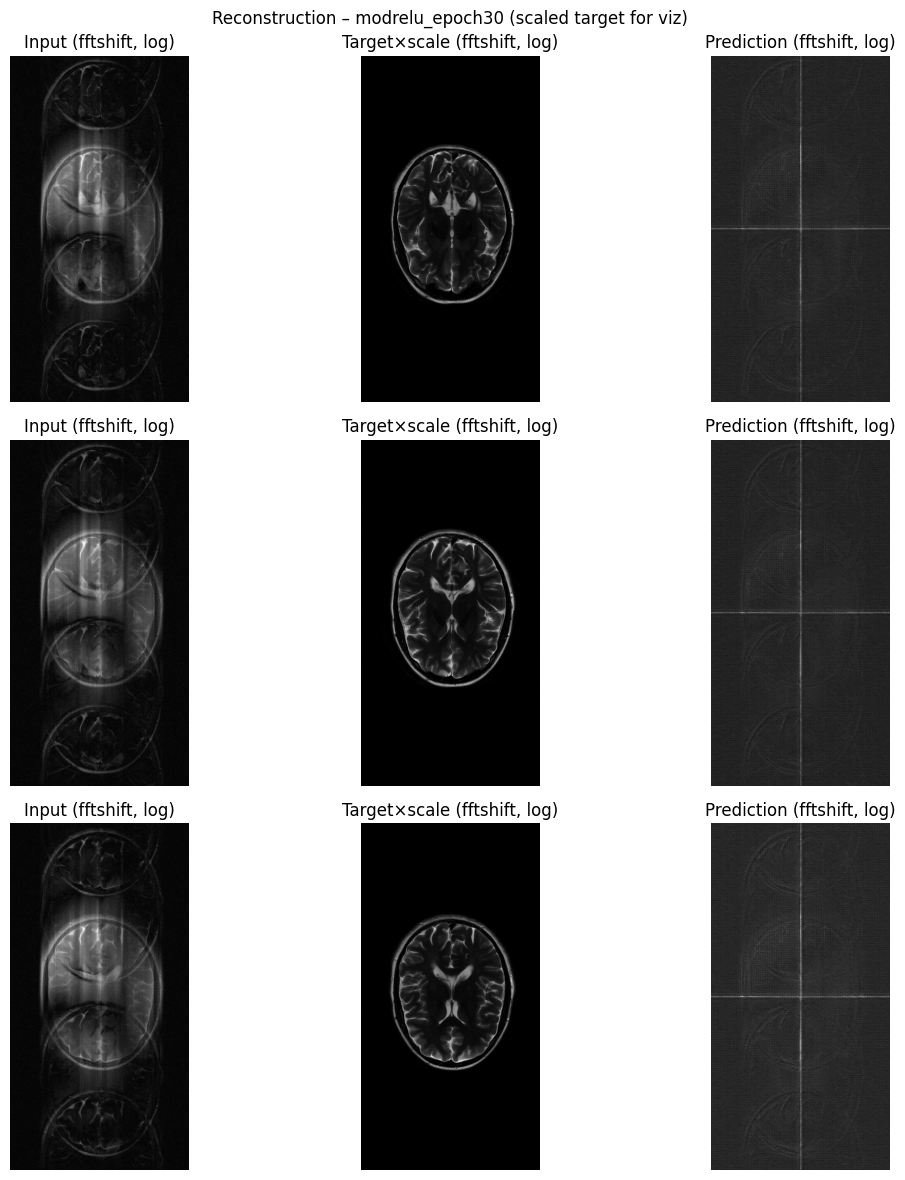

In [ ]:


step_size = 1e-3

for act_name in activations_to_test:
    print(f"\n=== Testing activation: {act_name} ===")
    model = ComplexMRIUNetSmall(act_name=act_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=step_size)

    for epoch in range(1, 30):
        train_one_epoch(model, cv_train_loader, optimizer, epoch, act_name)
        evaluate(model, cv_val_loader, act_name)

    visualize_reconstruction_scaled(model, cv_val_loader, num_samples=3, tag=f"{act_name}_epoch{epoch+1}")
    


In [109]:
print("Available layers in torchcvnn.nn:")
for name in dir(c_nn):
    if not name.startswith('_'):
        print(f"  - {name}")

Available layers in torchcvnn.nn:
  - AdaptiveAvgPool2d
  - AvgPool2d
  - BatchNorm1d
  - BatchNorm2d
  - CCELU
  - CELU
  - CGELU
  - CPReLU
  - CReLU
  - CSigmoid
  - CTanh
  - Cardioid
  - ComplexMSELoss
  - ConvTranspose2d
  - Dropout
  - Dropout2d
  - LayerNorm
  - MaxPool2d
  - Mod
  - MultiheadAttention
  - RMSNorm
  - Transformer
  - TransformerDecoderLayer
  - TransformerEncoder
  - TransformerEncoderLayer
  - Upsample
  - ViT
  - ViTLayer
  - activation
  - batchnorm
  - conv
  - dropout
  - functional
  - init
  - initialization
  - loss
  - modReLU
  - modules
  - normalization
  - pooling
  - transformer
  - upsampling
  - vit
  - zAbsReLU
  - zLeakyReLU
  - zReLU


In [150]:
class SingleFastMRIDatasetReal(Dataset):
    def __init__(self, path, accel=4, max_slices=None):
        self.inner = SingleFastMRIDataset(path, accel=accel, max_slices=max_slices)

    def __len__(self):
        return len(self.inner)

    def __getitem__(self, idx):
        X_complex, Y_target = self.inner[idx]      # X_complex: [1,H,W] complex
        # Convert to 2-channel real: [2,H,W]
        xr = torch.view_as_real(X_complex)        # [1,H,W,2]
        xr = xr.squeeze(0).permute(2, 0, 1)       # [2,H,W]
        X_real = xr.float()
        return X_real, Y_target.float()


In [151]:
train_ds_real = SingleFastMRIDatasetReal(train_path, accel=4, max_slices=2000)
val_ds_real   = SingleFastMRIDatasetReal(val_path,   accel=4, max_slices=500)

rv_train_loader = DataLoader(train_ds_real, batch_size=4, shuffle=True,
                             num_workers=4, pin_memory=True)
rv_val_loader   = DataLoader(val_ds_real,   batch_size=4, shuffle=False,
                             num_workers=4, pin_memory=True)


In [156]:
class RealMRIUNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        act = nn.ReLU(inplace=True)

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
        )
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
        )
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            act,
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            act,
        )

        # Decoder level 2 (H/4 → H/2)
        self.up2 = nn.ConvTranspose2d(
            64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        # after concat: 32 (up) + 32 (enc2) = 64
        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
        )

        # Decoder level 1 (H/2 → H)
        self.up1 = nn.ConvTranspose2d(
            32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        # after concat: 16 (up) + 16 (enc1) = 32
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
        )

        self.out_conv = nn.Conv2d(16, 1, kernel_size=3, padding=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, e2], dim=1)  # [B,64,H/2,W/2]
        d2 = self.dec2(u2)               # [B,32,H/2,W/2]

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)  # [B,32,H,W]
        d1 = self.dec1(u1)               # [B,16,H,W]

        out = self.out_conv(d1)          # [B,1,H,W]
        return out


In [170]:
def visualize_reconstruction_scaled_real(model, val_loader, num_samples=3, tag="RealUNet"):
    model.eval()
    with torch.no_grad():
        x, y = next(iter(val_loader))
        x = x.to(device)      # [B,2,H,W] float
        y = y.to(device)      # [B,1,H,W] float

        y_hat = model(x)      # [B,1,H,W] float

        x_cpu = x.cpu()
        y_cpu = y.cpu()
        y_hat_cpu = y_hat.cpu()

        def norm_img(img):
            vmin, vmax = img.min(), img.max()
            if vmax > vmin:
                return (img - vmin) / (vmax - vmin)
            else:
                return np.zeros_like(img)

        fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            in_mag   = np.fft.fftshift(np.abs(x_cpu[i,0].numpy()))
            tgt_mag  = np.fft.fftshift(y_cpu[i,0].numpy())
            pred_mag = np.fft.fftshift(y_hat_cpu[i,0].numpy())

            print(f"Sample {i}: in[{in_mag.min():.3e},{in_mag.max():.3e}] "
                  f"tgt[{tgt_mag.min():.3e},{tgt_mag.max():.3e}] "
                  f"pred[{pred_mag.min():.3e},{pred_mag.max():.3e}]")

            # Optional: boost target for visualization only
            tgt_boost = tgt_mag * 1e3  # adjust factor if needed

            in_disp   = norm_img(np.log1p(in_mag))
            tgt_disp  = norm_img(np.log1p(tgt_boost))
            pred_disp = norm_img(np.log1p(pred_mag))

            axes[i,0].imshow(in_disp,   cmap="gray")
            axes[i,0].set_title("Input (fftshift, log)")
            axes[i,0].axis("off")

            axes[i,1].imshow(tgt_disp,  cmap="gray")
            axes[i,1].set_title("Target (scaled, fftshift, log)")
            axes[i,1].axis("off")

            axes[i,2].imshow(pred_disp, cmap="gray")
            axes[i,2].set_title("Prediction (fftshift, log)")
            axes[i,2].axis("off")

        print("orig target mean/std:", y.mean().item(), y.std().item())
        print("pred mean/std:", y_hat.mean().item(), y_hat.std().item())

        plt.suptitle(f"Reconstruction – {tag}")
        plt.tight_layout()
        plt.show()


In [162]:
def real_mse(pred, target):
    # both [B,1,H,W] real
    # if shapes ever differ (they shouldn't with this U-Net), you can interpolate target
    diff = pred - target
    return (diff ** 2).mean()


In [163]:
def train_one_epoch_real(model, loader, optimizer, epoch, tag="Real"):
    model.train()
    total_loss, total = 0.0, 0
    for x, y in tqdm(loader, desc=f"[{tag}] Train {epoch}", leave=False):
        x = x.to(device)   # [B,2,H,W] float
        y = y.to(device)   # [B,1,H,W] float

        optimizer.zero_grad()
        y_hat = model(x)   # [B,1,H,W] float
        loss = real_mse(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    print(f"[{tag}] Epoch {epoch} | loss={total_loss/total:.6f}")


def evaluate_real(model, loader, tag="Real"):
    model.eval()
    total_loss, total = 0.0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"[{tag}] Eval", leave=False):
            x = x.to(device)
            y = y.to(device)
            y_hat = model(x)
            loss = real_mse(y_hat, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)
    avg_loss = total_loss / total
    print(f"[{tag}] Val | loss={avg_loss:.6f}")
    return avg_loss


[RealUNet] Train 0:   0%|          | 0/4 [00:00<?, ?it/s]

[RealUNet] Epoch 0 | loss=0.056214


[RealUNet] Val | loss=0.002483


[RealUNet] Epoch 1 | loss=0.007109


[RealUNet] Val | loss=0.001874


...

[RealUNet] Epoch 28 | loss=0.000134


[RealUNet] Val | loss=0.001699


[RealUNet] Epoch 29 | loss=0.000129


[RealUNet] Val | loss=0.004112


Sample 0: in[9.743e-11,2.928e-04] tgt[1.001e-04,6.651e-04] pred[-3.265e-01,2.094e-01]
Sample 1: in[1.564e-10,2.910e-04] tgt[1.001e-04,5.867e-04] pred[-3.474e-01,1.907e-01]
Sample 2: in[3.604e-11,3.059e-04] tgt[1.001e-04,6.697e-04] pred[-3.716e-01,2.181e-01]
orig target mean/std: 0.00011980719864368439 4.876314051216468e-05
pred mean/std: -0.03853565827012062 0.04980919510126114


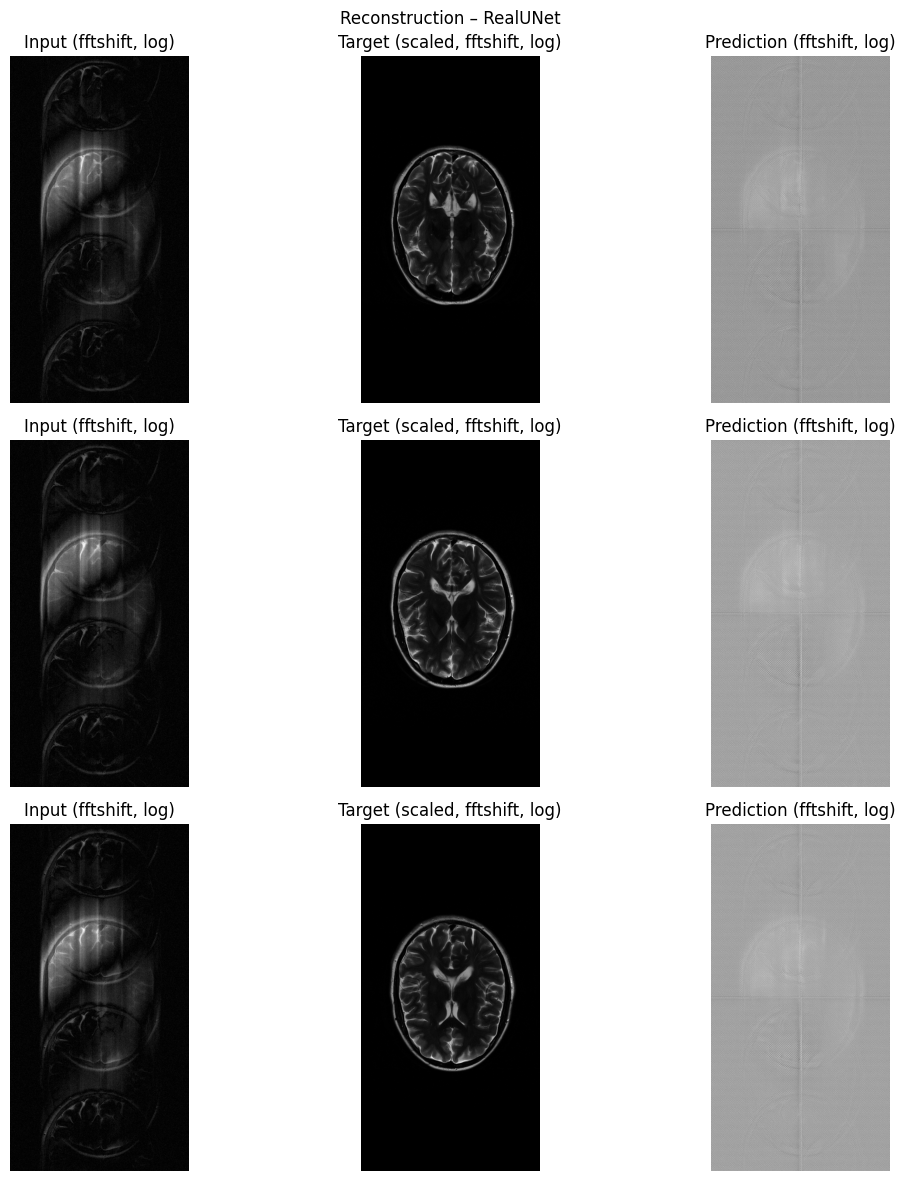

In [172]:
real_model = RealMRIUNetSmall().to(device)
optimizer_real = optim.Adam(real_model.parameters(), lr=1e-3)

for epoch in range(0, 30):
    train_one_epoch_real(real_model, rv_train_loader, optimizer_real, epoch, tag="RealUNet")
    evaluate_real(real_model, rv_val_loader, tag="RealUNet")


visualize_reconstruction_scaled_real(real_model, rv_val_loader, num_samples=3, tag="RealUNet")
